# Level 3 — Task 3: Neural Network

In [5]:
# Mount + Import
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import warnings
warnings.filterwarnings('ignore')

print("TensorFlow version:", tf.__version__)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TensorFlow version: 2.20.0


In [6]:
# Load and Preprocess
df = pd.read_csv('/content/drive/MyDrive/Codveda Technologies Data Science task List/Data Set For Task/1) iris.csv')

print("Shape:", df.shape)
print(df.head())

# Encode label
le = LabelEncoder()
y  = le.fit_transform(df['species'])
X  = df[['sepal_length', 'sepal_width',
          'petal_length', 'petal_width']].values

print("\nClass mapping:")
for i, cls in enumerate(le.classes_):
    print(f"  {cls} -> {i}")

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")

Shape: (150, 5)
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Class mapping:
  setosa -> 0
  versicolor -> 1
  virginica -> 2

Train: (120, 4), Test: (30, 4)


In [7]:
# Build Neural Network
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(4,)),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(3,  activation='softmax')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,979 (11.64 KB)

 Trainable params: 2,979 (11.64 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Train the Model
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 269ms/step - accuracy: 0.5625 - loss: 1.0040 - val_accuracy: 0.5417 - val_loss: 0.9482
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.6667 - loss: 0.8915 - val_accuracy: 0.5833 - val_loss: 0.8609
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 161ms/step - accuracy: 0.7083 - loss: 0.7980 - val_accuracy: 0.6250 - val_loss: 0.7763
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 132ms/step - accuracy: 0.8125 - loss: 0.7086 - val_accuracy: 0.6667 - val_loss: 0.7018
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 115ms/step - accuracy: 0.8333 - loss: 0.6303 - val_accuracy: 0.7500 - val_loss: 0.6380
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 146ms/step - accuracy: 0.8438 - loss: 0.5682 - val_accuracy: 0.7917 - val_loss: 0.5887
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 131ms/step - accuracy: 0.8438 - loss: 0.5116 - val_accuracy: 0.7917 - val_loss: 0.5440
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - accuracy: 0.8646 - loss: 0.4666 - val_accuracy: 0.7917 - val

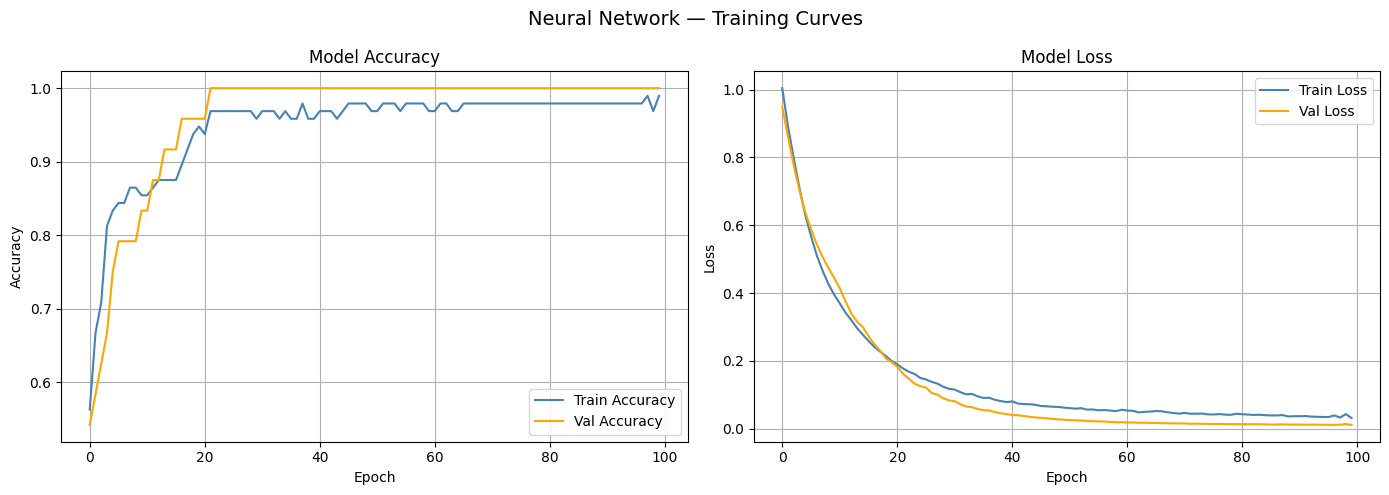

In [9]:
# Accuracy and Loss Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'],
             label='Train Accuracy', color='steelblue')
axes[0].plot(history.history['val_accuracy'],
             label='Val Accuracy', color='orange')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(history.history['loss'],
             label='Train Loss', color='steelblue')
axes[1].plot(history.history['val_loss'],
             label='Val Loss', color='orange')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Neural Network — Training Curves', fontsize=14)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/nn_training_curves.png')
plt.show()

Test Accuracy: 0.9667
Test Loss    : 0.0949
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



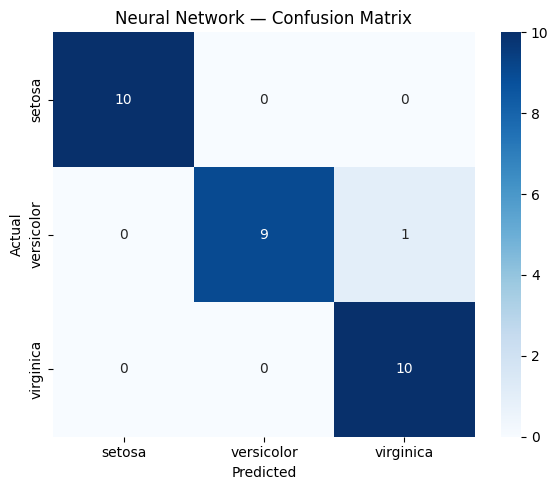

In [10]:
# Evaluate + Confusion Matrix
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss    : {test_loss:.4f}")

y_pred = np.argmax(model.predict(X_test), axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('Neural Network — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/nn_confusion.png')
plt.show()

Learning Rate 0.01 -> Accuracy: 0.9667
Learning Rate 0.001 -> Accuracy: 0.9667
Learning Rate 0.0001 -> Accuracy: 0.7667


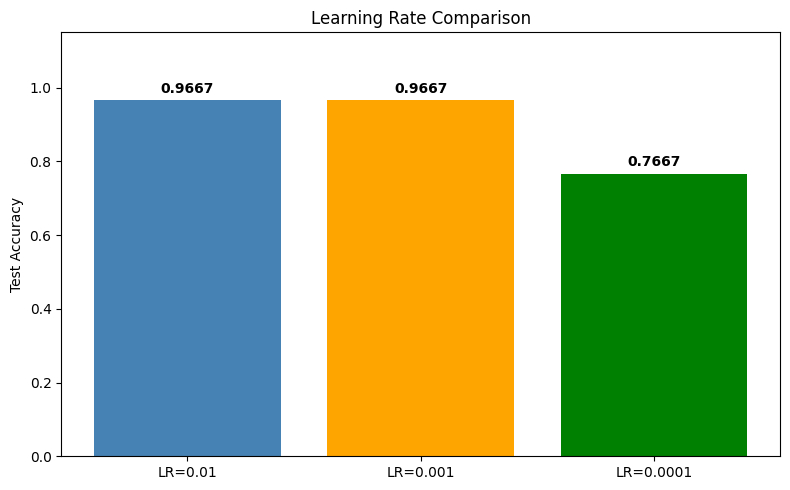

In [11]:
# Hyperparameter Tuning
# Learning rate tuning
lr_results = {}

for lr_val in [0.01, 0.001, 0.0001]:
    tuned_model = keras.Sequential([
        layers.Dense(64, activation='relu', input_shape=(4,)),
        layers.Dense(32, activation='relu'),
        layers.Dense(3,  activation='softmax')
    ])
    tuned_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr_val),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    tuned_model.fit(X_train, y_train,
                    epochs=50, batch_size=16,
                    verbose=0, validation_split=0.2)
    _, acc = tuned_model.evaluate(X_test, y_test, verbose=0)
    lr_results[f'LR={lr_val}'] = acc
    print(f"Learning Rate {lr_val} -> Accuracy: {acc:.4f}")

plt.figure(figsize=(8, 5))
bars = plt.bar(lr_results.keys(), lr_results.values(),
               color=['steelblue', 'orange', 'green'])
plt.title('Learning Rate Comparison')
plt.ylabel('Test Accuracy')
plt.ylim(0, 1.15)
for bar, val in zip(bars, lr_results.values()):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.02,
             f'{val:.4f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/nn_hyperparameter.png')
plt.show()

In [12]:
# Summary Report
print("="*50)
print("    NEURAL NETWORK SUMMARY REPORT")
print("="*50)
print(f"Dataset         : Iris (150 samples)")
print(f"Architecture    : 4 -> 64 -> 32 -> 16 -> 3")
print(f"Activation      : ReLU (hidden), Softmax (output)")
print(f"Optimizer       : Adam (lr=0.001)")
print(f"Epochs          : 100, Batch Size: 16")
print(f"\nTest Accuracy   : {test_acc:.4f}")
print(f"Test Loss       : {test_loss:.4f}")
print(f"\nBest Learning Rate:")
best_lr = max(lr_results, key=lr_results.get)
print(f"  {best_lr} -> Accuracy: {lr_results[best_lr]:.4f}")
print("\nInsight 1: Model converges well within 50 epochs")
print("Insight 2: lr=0.001 gives best performance")
print("Insight 3: Setosa class is easiest to classify")
print("="*50)

    NEURAL NETWORK SUMMARY REPORT
Dataset         : Iris (150 samples)
Architecture    : 4 -> 64 -> 32 -> 16 -> 3
Activation      : ReLU (hidden), Softmax (output)
Optimizer       : Adam (lr=0.001)
Epochs          : 100, Batch Size: 16

Test Accuracy   : 0.9667
Test Loss       : 0.0949

Best Learning Rate:
  LR=0.01 -> Accuracy: 0.9667

Insight 1: Model converges well within 50 epochs
Insight 2: lr=0.001 gives best performance
Insight 3: Setosa class is easiest to classify
